In [2]:
import pandas as pd

# 1) 엑셀 파일 읽기 (파일이 같은 폴더에 있다고 가정)
#    경로가 다르면 "fomc_statement_minutes.xlsx" 부분만 수정하면 됨.
fomc = pd.read_excel("fomc_statement_minutes.xlsx")

# 2) meeting_id를 문자열로 변환 (예: 'fomc_20060131')
fomc["meeting_id"] = fomc["meeting_id"].astype(str)

# 3) meeting_id에서 YYYYMMDD 8자리 숫자만 추출
#    예: 'fomc_20060131' -> '20060131'
date_str = fomc["meeting_id"].str.extract(r"(\d{8})")[0]

# 4) datetime으로 변환해서 meeting_date 컬럼 생성
fomc["meeting_date"] = pd.to_datetime(date_str, format="%Y%m%d")

# 5) doc_type을 소문자로 통일
fomc["doc_type"] = fomc["doc_type"].astype(str).str.lower()

# 6) statement만 필터링
fomc_statement = fomc[fomc["doc_type"] == "statement"].copy()

print("statement 개수:", len(fomc_statement))
print(fomc_statement[["meeting_id", "meeting_date"]].head())


statement 개수: 171
      meeting_id meeting_date
0  FOMC_20060131   2006-01-31
2  FOMC_20060328   2006-03-28
4  FOMC_20060510   2006-05-10
6  FOMC_20060629   2006-06-29
8  FOMC_20060808   2006-08-08


In [3]:
# meeting_date 기준으로 정렬 후 가장 최근 성명문 1개 선택
latest_statement = fomc_statement.sort_values("meeting_date").iloc[-1]

latest_date = latest_statement["meeting_date"]
latest_text = str(latest_statement["text"])  # 혹시 NaN 방지

print("가장 최근 성명문 날짜:", latest_date)
print("\n--- 텍스트 앞 500자 ---")
print(latest_text[:500], "...")


가장 최근 성명문 날짜: 2025-10-29 00:00:00

--- 텍스트 앞 500자 ---
October 29, 2025

For release at 2:00 p.m. EDT

Available indicators suggest that economic activity has been expanding at a moderate pace. Job gains have slowed this year, and the unemployment rate has edged up but remained low through August; more recent indicators are consistent with these developments. Inflation has moved up since earlier in the year and remains somewhat elevated.

The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run. Un ...


In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1) 사용할 모델 이름
#    - 기본: ProsusAI/finbert (3 클래스용 원모델)
#    - 파인튜닝 모델이 있으면 그 경로(또는 허브 이름)로 교체
MODEL_NAME = "ProsusAI/finbert"  # 예시

# 2) 토크나이저 & 모델 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# num_labels=2로 새 분류 헤드 생성, ignore_mismatched_sizes=True 로 마지막 레이어만 새로 맞춰줌
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "DOVISH", 1: "HAWKISH"},
    label2id={"DOVISH": 0, "HAWKISH": 1},
    ignore_mismatched_sizes=True,
).to(device)

model.eval()


/opt/anaconda3/envs/TDM_lab/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [5]:
import torch
from captum.attr import IntegratedGradients
import numpy as np

# 1) 텍스트 토크나이즈
encoding = tokenizer(
    latest_text,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

input_ids = encoding["input_ids"].to(device)          # (1, seq_len)
attention_mask = encoding["attention_mask"].to(device)

# 2) 임베딩 벡터 뽑기
#    model 구조가 BertForSequenceClassification이라면 .bert.embeddings 사용 가능
with torch.no_grad():
    inputs_embeds = model.bert.embeddings(input_ids=input_ids)  # (1, seq_len, hidden_dim)


In [6]:
def forward_emb(inputs_embeds, attention_mask):
    """
    inputs_embeds: (batch, seq_len, hidden_dim)
    attention_mask: (batch, seq_len)
    -> 반환: hawkish 클래스 logit (batch,)
    """
    outputs = model(
        inputs_embeds=inputs_embeds,
        attention_mask=attention_mask
    )
    # 0 = DOVISH, 1 = HAWKISH 라벨이라고 우리가 지정했으니까
    hawk_idx = 1
    logits = outputs.logits  # (batch, num_labels)
    return logits[:, hawk_idx]


In [7]:
# 3) IG 객체 생성
ig = IntegratedGradients(forward_emb)

# 4) baseline: 전부 0인 임베딩 (같은 shape)
baseline_embeds = torch.zeros_like(inputs_embeds).to(device)

# 5) 속성(attributions) 계산
attributions, delta = ig.attribute(
    inputs=inputs_embeds,
    baselines=baseline_embeds,
    additional_forward_args=(attention_mask,),
    return_convergence_delta=True
)

# attributions: (1, seq_len, hidden_dim)
attr = attributions.squeeze(0).detach().cpu().numpy()  # (seq_len, hidden_dim)

# 6) 토큰별 스코어로 축소 (hidden_dim 방향 합/평균)
token_scores = attr.sum(axis=-1)  # (seq_len,)

# 정규화 (길이 1로)
token_scores = token_scores / (np.linalg.norm(token_scores) + 1e-10)

# 7) 토큰 id -> 실제 토큰 문자열
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])


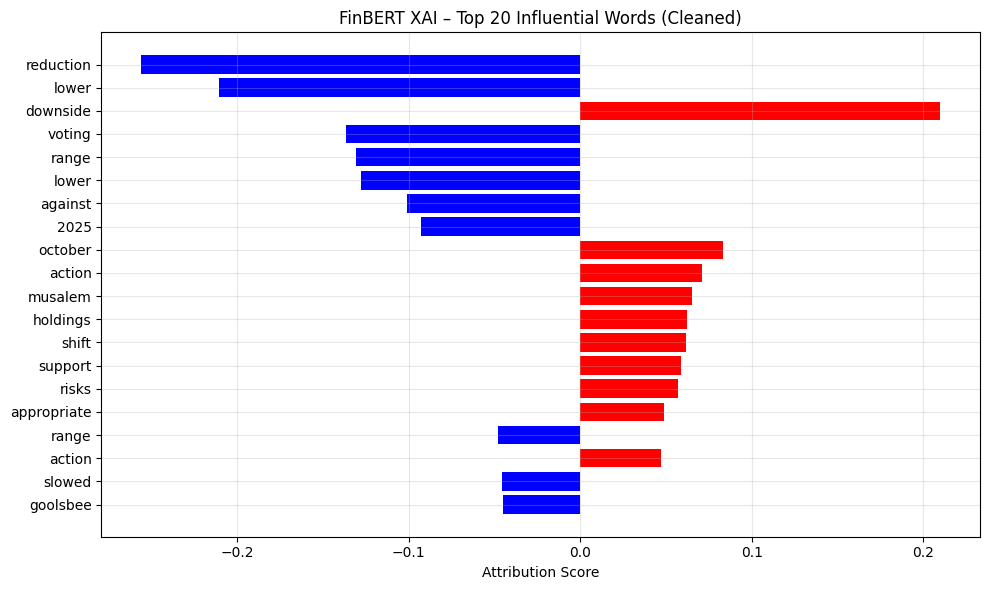

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def merge_wordpiece_tokens(tokens, scores):
    """
    BERT WordPiece 토큰을 단어 수준으로 재조합하고
    각 단어별 attribution 점수(합)를 반환.
    """
    words = []
    word_scores = []

    current_word = ""
    current_score = 0.0

    for tok, s in zip(tokens, scores):
        # 특수 토큰은 일단 그대로 따로 처리 (필터링은 나중 단계에서)
        if tok in ["[CLS]", "[SEP]", "[PAD]"]:
            if current_word:
                words.append(current_word)
                word_scores.append(current_score)
                current_word, current_score = "", 0.0

            words.append(tok)
            word_scores.append(s)
            continue

        # WordPiece 정리: ▁, ## 제거
        clean = tok.replace("▁", "")
        if clean.startswith("##"):
            piece = clean[2:]
            current_word += piece
            current_score += s
        else:
            if current_word:
                words.append(current_word)
                word_scores.append(current_score)
            current_word = clean
            current_score = s

    if current_word:
        words.append(current_word)
        word_scores.append(current_score)

    return np.array(words), np.array(word_scores)


def plot_topN_word_importances(tokens, token_scores, top_n=20, title=None):
    # 1) WordPiece -> 단어로 합치기
    words, word_scores = merge_wordpiece_tokens(tokens, token_scores)

    # 2) 특수 토큰 / 구두점 / stopword 필터링
    ignore_tokens = {"[CLS]", "[SEP]", "[PAD]", ""}
    punctuation = {".", ",", ";", ":", "-", "--", "(", ")", "'", '"'}
    stopwords = {
        "the","and","to","of","in","for","on","by","with","at","from",
        "this","that","these","those","is","are","was","were","be","been",
        "a","an","as","it","its","will","shall","would","should","can",
        "could","may","might","we","our","they","their","there","here"
    }

    filtered = []
    for w, s in zip(words, word_scores):
        wl = w.lower()
        if w in ignore_tokens:
            continue
        if wl in stopwords:
            continue
        if wl in punctuation:
            continue
        # 숫자만 있는 경우도 제외하고 싶으면 아래 추가
        # if wl.replace(".","").isdigit():
        #     continue
        filtered.append((w, s))

    if not filtered:
        print("필터링 후 남은 단어가 없습니다. stopword/조건을 완화해보세요.")
        return

    fw, fs = zip(*filtered)
    fw = np.array(fw)
    fs = np.array(fs)

    # 3) 상위 N개 선택 (절댓값 기준)
    abs_scores = np.abs(fs)
    top_idx = abs_scores.argsort()[::-1][:top_n]

    top_words = fw[top_idx]
    top_vals  = fs[top_idx]

    # 보기 좋게 다시 정렬
    order = np.argsort(np.abs(top_vals))[::-1]
    top_words = top_words[order]
    top_vals  = top_vals[order]

    colors = ["red" if v > 0 else "blue" for v in top_vals]

    # 4) 막대그래프
    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(top_words))
    plt.barh(y_pos, top_vals, color=colors)
    plt.yticks(y_pos, top_words, fontsize=10)
    plt.xlabel("Attribution Score")

    if title is None:
        title = f"Top {len(top_words)} Words by Attribution Importance"
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 사용 예시
plot_topN_word_importances(tokens, token_scores, top_n=20,
                           title="FinBERT XAI – Top 20 Influential Words (Cleaned)")


In [ ]:
'''  
위의 막대그래프는 가장 최근 성명문을 가지고 분석한 것 '''